<a href="https://colab.research.google.com/github/arnavon2005/Army_Provost_ML_Project/blob/main/04_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# PROJECT:
# Control Room - Applying Machine Learning Algorithms for Enabling
# Indian Army Provost Functioning
# ==============================================================================
#
# PHASE 5 : EXPLORATORY DATA ANALYSIS (EDA)
#
# Developer : Arnav Sharma
# Platform  : Google Colab
#
# Purpose:
# This notebook performs Exploratory Data Analysis (EDA) on the cleaned
# Chicago Crimes and Montgomery Police Dispatch datasets.
#
# Cleaned datasets generated from:
# 03_Data_Cleaning.ipynb
#
# ==============================================================================

In [2]:
# ==========================================================
# SECTION 1 : MOUNT GOOGLE DRIVE
# ==========================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [3]:
# ==========================================================
# SECTION 2 : PROJECT CONFIGURATION
# ==========================================================

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Army_Provost_ML_Project")

RAW_DATASET_PATH = PROJECT_ROOT / "Datasets" / "Raw"
CLEAN_DATASET_PATH = PROJECT_ROOT / "Datasets" / "Cleaned"

MODEL_PATH = PROJECT_ROOT / "Models"
FIGURE_PATH = PROJECT_ROOT / "Figures"
REPORT_PATH = PROJECT_ROOT / "Reports"
OUTPUT_PATH = PROJECT_ROOT / "Outputs"

print("Project configured successfully.")
print(f"Project Root : {PROJECT_ROOT}")

Project configured successfully.
Project Root : /content/drive/MyDrive/Army_Provost_ML_Project


In [4]:
# ==========================================================
# SECTION 3 : IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# ==========================================================
# SECTION 4 : LOAD CLEANED DATASETS
# ==========================================================

print("=" * 80)
print("LOADING CLEANED DATASETS")
print("=" * 80)

chicago_df = pd.read_csv(
    CLEAN_DATASET_PATH / "chicago_crimes_cleaned.csv",
    low_memory=False
)

montgomery_df = pd.read_csv(
    CLEAN_DATASET_PATH / "montgomery_dispatch_cleaned.csv",
    low_memory=False
)

print("\nDatasets loaded successfully.\n")

print("Chicago Crimes Shape:")
print(chicago_df.shape)

print()

print("Montgomery Dispatch Shape:")
print(montgomery_df.shape)

LOADING CLEANED DATASETS

Datasets loaded successfully.

Chicago Crimes Shape:
(8602734, 22)

Montgomery Dispatch Shape:
(1886836, 26)


In [6]:
# ==========================================================
# SECTION 5 : VERIFY DATA
# ==========================================================

print("=" * 80)
print("CHICAGO DATASET")
print("=" * 80)

display(chicago_df.head())

print()

print("=" * 80)
print("MONTGOMERY DATASET")
print("=" * 80)

display(montgomery_df.head())

CHICAGO DATASET


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,14269678,JK342166,2026-07-20 00:00:00,001XX E WACKER DR,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOTEL / MOTEL,False,False,114,1.0,42.0,32.0,02,1177683.0,1902638.0,2026,2026-07-27 15:43:52,41.888165,-87.622940,"(41.888165132, -87.622937212)"
1,14267487,JK340097,2026-07-20 00:00:00,084XX S MARYLAND AVE,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,632,6.0,8.0,44.0,14,1183361.0,1849252.0,2026,2026-07-27 15:43:52,41.741540,-87.603750,"(41.741539131, -87.603750482)"
2,14267485,JK340089,2026-07-20 00:00:00,105XX S WABASH AVE,0486,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,512,5.0,9.0,49.0,08B,1178438.0,1835166.0,2026,2026-07-27 15:43:52,41.703000,-87.622215,"(41.70299844, -87.622214313)"
3,14268664,JK341413,2026-07-20 00:00:00,091XX S LAFAYETTE AVE,0810,THEFT,OVER $500,RESIDENCE,False,True,634,6.0,9.0,49.0,06,1177542.0,1844332.0,2026,2026-07-27 15:43:52,41.728172,-87.625220,"(41.728171435, -87.625219193)"
4,14269513,JK342626,2026-07-20 00:00:00,028XX N KIMBALL AVE,4387,OTHER OFFENSE,VIOLATE ORDER OF PROTECTION,APARTMENT,False,False,1412,14.0,35.0,21.0,26,1153219.0,1919032.0,2026,2026-07-27 15:43:52,41.933674,-87.712340,"(41.933672358, -87.712341606)"



MONTGOMERY DATASET


,Incident_ID,Crime Reports,Crash Reports,Start Time,End Time,Priority,Initial Type,Close Type,Address,City,State,Zip,Longitude,Latitude,Police District Number,Beat,PRA,CallTime CallRoute,Calltime Dispatch,Calltime Arrive,Calltime Cleared,CallRoute Dispatch,Dispatch Arrive,Arrive Cleared,Disposition Desc,Location
0,P2600225594,NaN,NaN,2026-07-29 00:25:24,2026-07-29 00:35:05,2,TRAFFIC/TRANSPORTATION INCIDENT,TRAFFIC/TRANSPORTATION INCIDENT,18500 BLK BOYSENBERRY DR,GAITHERSBURG,MD,20879,-77.2071,39.15975,6D,R1,766,225.0,261.0,NaN,581.0,36.0,NaN,NaN,COLOTH-DAMAG-PRKG-HITRUN,POINT (-77.2071 39.1598)
1,P2600225531,NaN,NaN,2026-07-28 22:39:32,2026-07-29 00:32:39,1,"WANTED PERSON, VEHICLE","WANTED PERSON, VEHICLE",10500 BLK CONNECTICUT AVE,KENSINGTON,MD,20895,-77.0766,39.02748,2D,D1,179,349.0,846.0,1427.0,6787.0,497.0,580.0,5359.0,OTHERMISCELLANEOUS,POINT (-77.0766 39.0275)
2,P2600225569,NaN,NaN,2026-07-28 23:45:58,2026-07-29 00:32:26,1,CDS,CDS,11200 BLK GEORGIA AVE,SILVER SPRING,MD,20902,NaN,NaN,4D,L2,354,298.0,591.0,2101.0,2788.0,292.0,1509.0,687.0,SUSPICIOUSSIT/PRSON/VEH,POINT (0 0)
3,P2600225587,NaN,NaN,2026-07-29 00:12:14,2026-07-29 00:29:40,1,"SUSPICIOUS CIRC, PERSONS, VEHICLE","SUSPICIOUS CIRC, PERSONS, VEHICLE",1100 BLK MAPLE AVE,ROCKVILLE,MD,20851,NaN,NaN,1D,A2,292,191.0,279.0,953.0,1046.0,88.0,674.0,92.0,OTHERMISCELLANEOUS,POINT (0 0)
4,P2600225575,NaN,NaN,2026-07-28 23:55:39,2026-07-29 00:28:49,0,ASLTJA,ASLTJA,1 BLK FEATHERWOOD CT,SILVER SPRING,MD,20904,-76.9723,39.05889,3D,I1,147,150.0,177.0,356.0,1990.0,26.0,178.0,1633.0,AGGASSLTFRARMSPS/PTNR,POINT (-76.9723 39.0589)


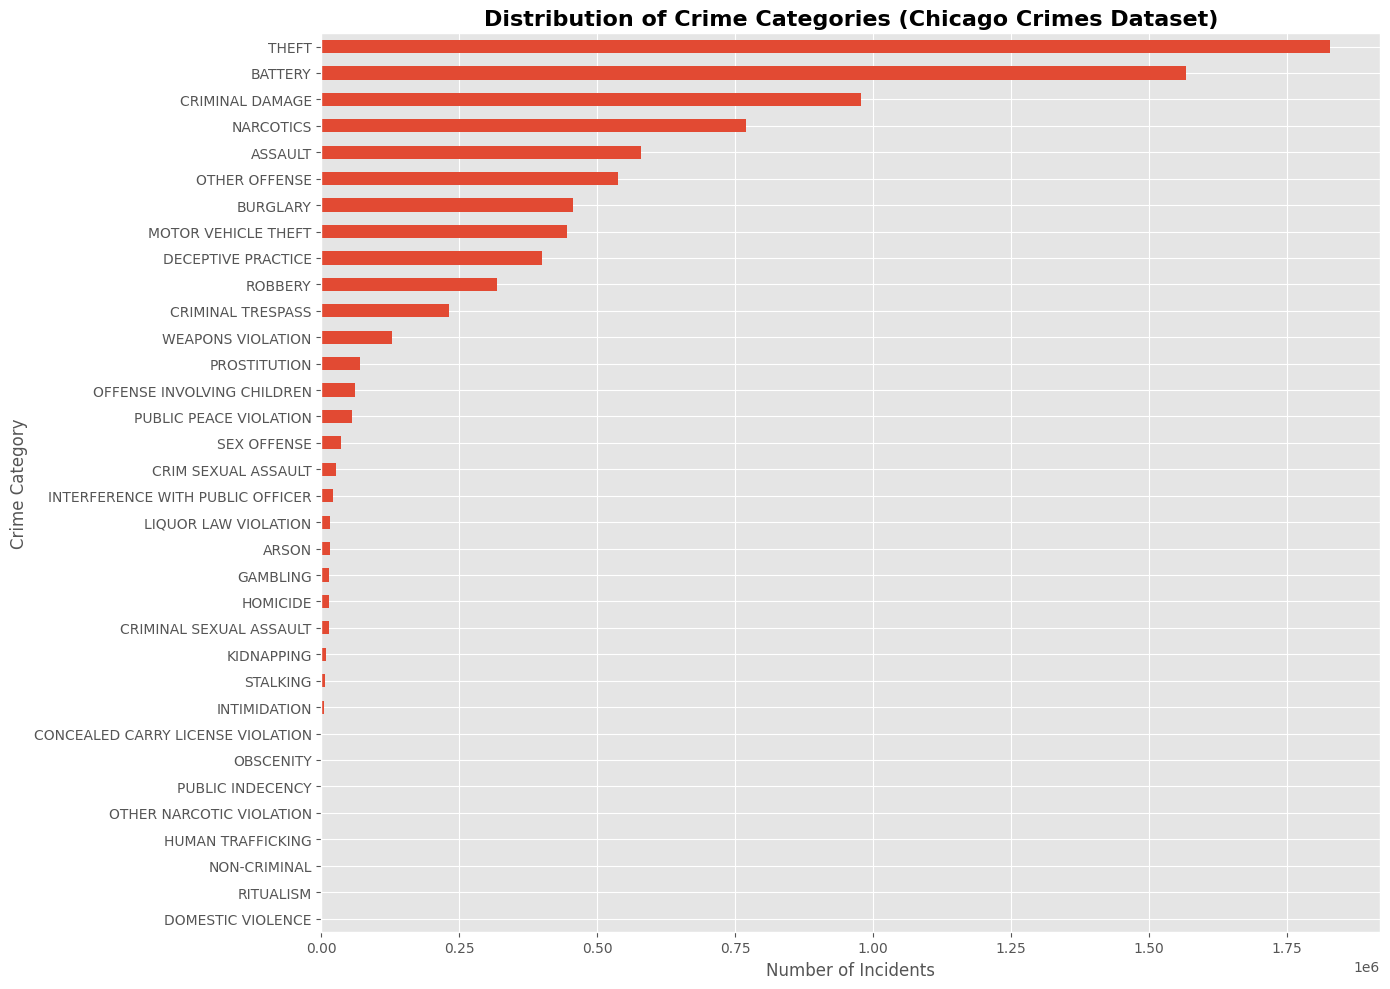

,Incident Count
Primary Type,
THEFT,1827377
BATTERY,1567212
CRIMINAL DAMAGE,977357
NARCOTICS,768704
ASSAULT,580094
OTHER OFFENSE,537540
BURGLARY,455436
MOTOR VEHICLE THEFT,444725
DECEPTIVE PRACTICE,400071


In [7]:
# ==========================================================
# EDA 1 : TOP CRIME CATEGORIES (CHICAGO)
# ==========================================================

import matplotlib.pyplot as plt

# Count incidents
crime_counts = (
    chicago_df["Primary Type"]
    .value_counts()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(14,10))

crime_counts.plot(kind="barh")

plt.title("Distribution of Crime Categories (Chicago Crimes Dataset)",
          fontsize=16,
          fontweight="bold")

plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("Crime Category", fontsize=12)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

# Display counts
display(
    crime_counts.to_frame(name="Incident Count")
)

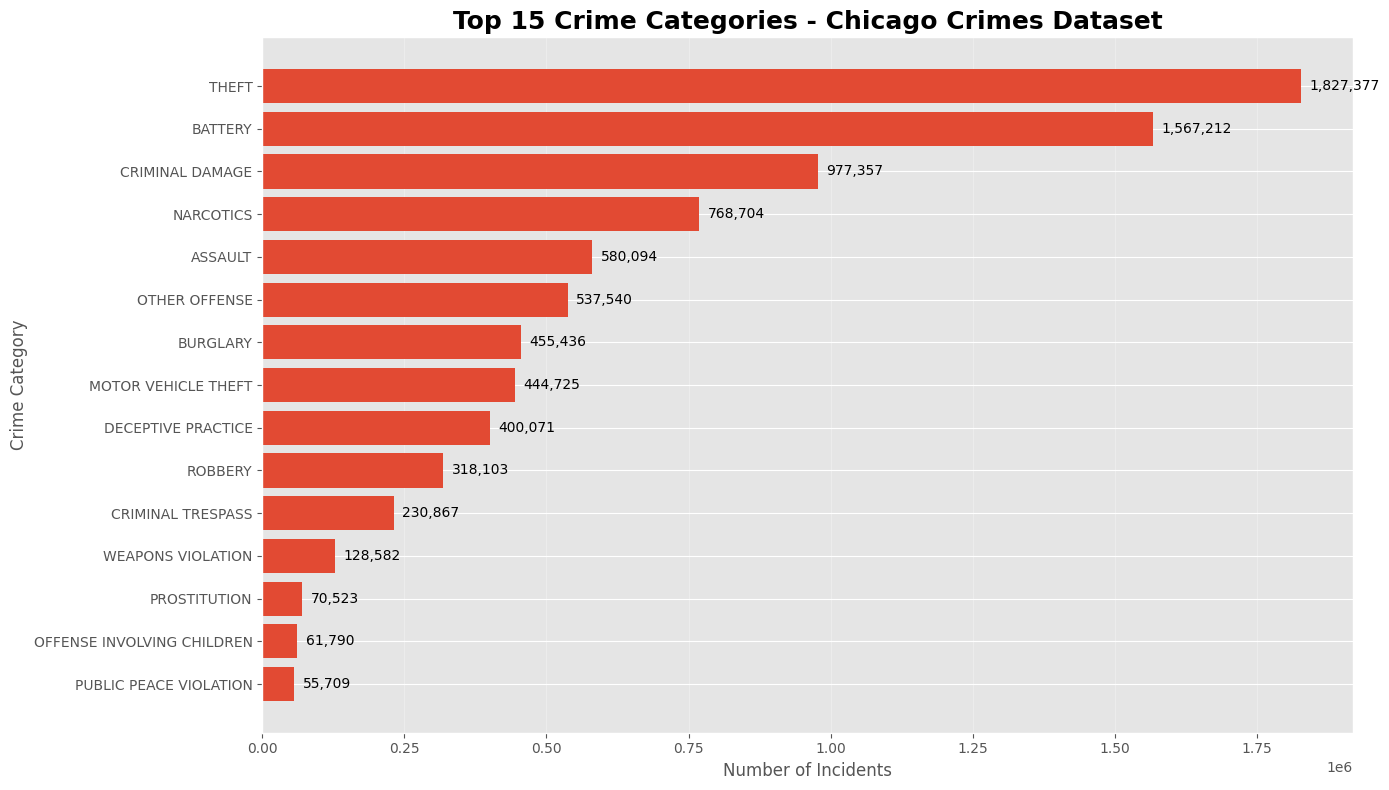

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Top15_Chicago_Crime_Categories.png


,Incident Count,Percentage
Primary Type,,
THEFT,1827377,21.24
BATTERY,1567212,18.22
CRIMINAL DAMAGE,977357,11.36
NARCOTICS,768704,8.94
ASSAULT,580094,6.74
OTHER OFFENSE,537540,6.25
BURGLARY,455436,5.29
MOTOR VEHICLE THEFT,444725,5.17
DECEPTIVE PRACTICE,400071,4.65


In [8]:
# ==========================================================
# EDA 2 : TOP 15 CRIME CATEGORIES (PROFESSIONAL)
# ==========================================================

import matplotlib.pyplot as plt

# -------------------------------
# Top 15 crime categories
# -------------------------------

top15_crimes = chicago_df["Primary Type"].value_counts().head(15)

# -------------------------------
# Create Figure
# -------------------------------

plt.figure(figsize=(14,8))

bars = plt.barh(
    top15_crimes.index[::-1],
    top15_crimes.values[::-1]
)

# -------------------------------
# Add value labels
# -------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 15000,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}",
        va='center',
        fontsize=10
    )

# -------------------------------
# Formatting
# -------------------------------

plt.title(
    "Top 15 Crime Categories - Chicago Crimes Dataset",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Incidents", fontsize=12)

plt.ylabel("Crime Category", fontsize=12)

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

figure_path = FIGURE_PATH / "Top15_Chicago_Crime_Categories.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# -------------------------------
# Percentage contribution
# -------------------------------

crime_summary = (
    chicago_df["Primary Type"]
    .value_counts()
    .head(15)
    .to_frame(name="Incident Count")
)

crime_summary["Percentage"] = (
    crime_summary["Incident Count"]
    / len(chicago_df)
    * 100
).round(2)

display(crime_summary)

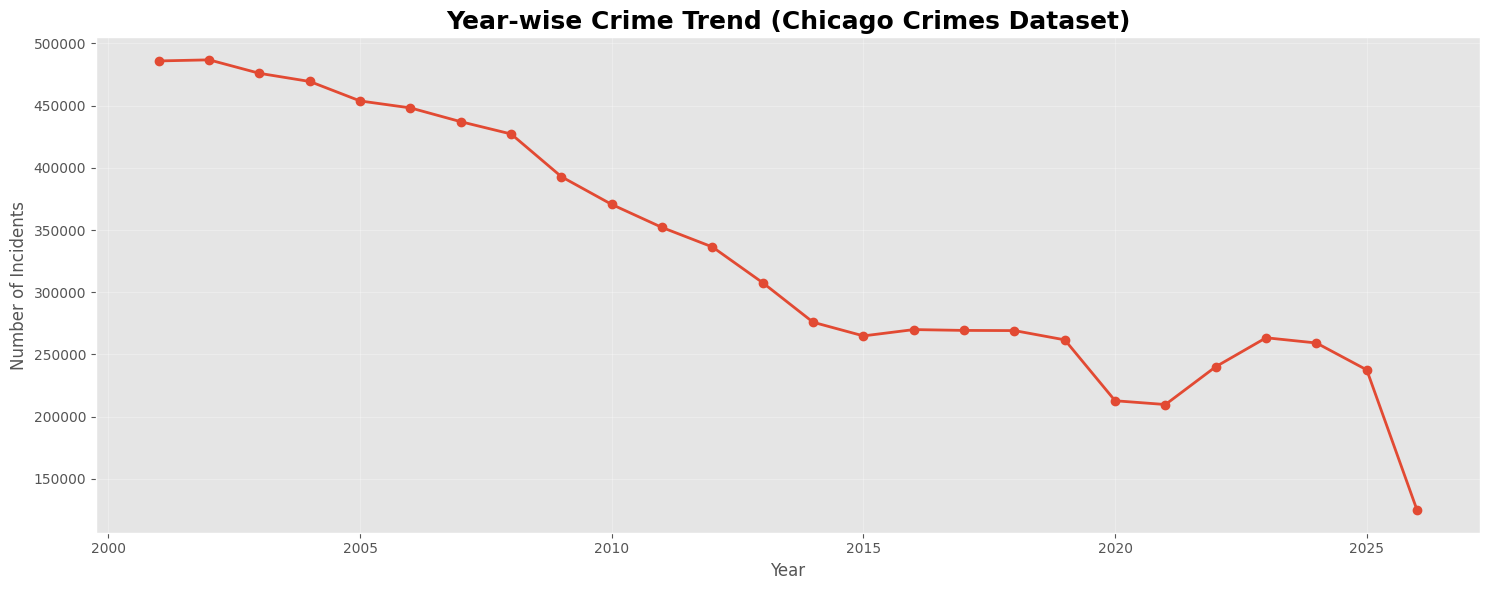

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Yearwise_Crime_Trend.png


,Incident Count
Year,
2001,485969
2002,486839
2003,476006
2004,469444
2005,453794
2006,448204
2007,437111
2008,427224
2009,392868


In [9]:
# ==========================================================
# EDA 3 : YEAR-WISE CRIME TREND
# ==========================================================

import matplotlib.pyplot as plt

# -------------------------------
# Count incidents per year
# -------------------------------

yearly_crimes = (
    chicago_df["Year"]
    .value_counts()
    .sort_index()
)

# -------------------------------
# Create Figure
# -------------------------------

plt.figure(figsize=(15,6))

plt.plot(
    yearly_crimes.index,
    yearly_crimes.values,
    marker="o",
    linewidth=2
)

# -------------------------------
# Formatting
# -------------------------------

plt.title(
    "Year-wise Crime Trend (Chicago Crimes Dataset)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Incidents", fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

# -------------------------------
# Save Figure
# -------------------------------

figure_path = FIGURE_PATH / "Yearwise_Crime_Trend.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 70)
print("Figure saved successfully:")
print(figure_path)
print("=" * 70)

# -------------------------------
# Display yearly counts
# -------------------------------

display(
    yearly_crimes.to_frame(name="Incident Count")
)

In [11]:
# ==========================================================
# Convert Date column back to datetime
# ==========================================================

chicago_df["Date"] = pd.to_datetime(
    chicago_df["Date"],
    errors="coerce"
)

print("Date datatype:", chicago_df["Date"].dtype)

Date datatype: datetime64[ns]


In [12]:
# ==========================================================
# Create Month Column
# ==========================================================

chicago_df["Month"] = chicago_df["Date"].dt.month

print("Month column created successfully.")

Month column created successfully.


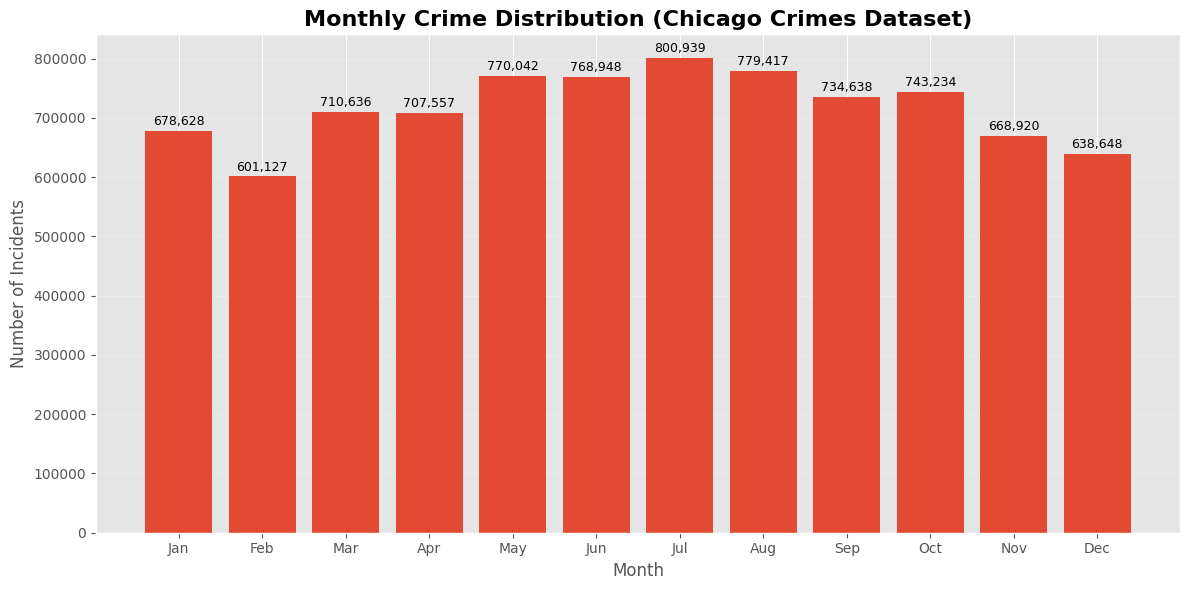

Figure saved successfully:
/content/drive/MyDrive/Army_Provost_ML_Project/Figures/Monthly_Crime_Distribution.png


,Incident Count
Month,
Jan,678628
Feb,601127
Mar,710636
Apr,707557
May,770042
Jun,768948
Jul,800939
Aug,779417
Sep,734638


In [13]:
# ==========================================================
# EDA 4 : MONTHLY CRIME DISTRIBUTION
# ==========================================================

import matplotlib.pyplot as plt

# --------------------------------
# Month Names
# --------------------------------

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec"
}

monthly_crime = (
    chicago_df["Month"]
    .value_counts()
    .sort_index()
)

monthly_crime.index = monthly_crime.index.map(month_names)

# --------------------------------
# Plot
# --------------------------------

plt.figure(figsize=(12,6))

bars = plt.bar(
    monthly_crime.index,
    monthly_crime.values
)

# --------------------------------
# Add value labels
# --------------------------------

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 10000,
        f"{height:,}",
        ha="center",
        fontsize=9
    )

# --------------------------------
# Formatting
# --------------------------------

plt.title(
    "Monthly Crime Distribution (Chicago Crimes Dataset)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Number of Incidents")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# --------------------------------
# Save Figure
# --------------------------------

figure_path = FIGURE_PATH / "Monthly_Crime_Distribution.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("="*70)
print("Figure saved successfully:")
print(figure_path)
print("="*70)

# --------------------------------
# Display Table
# --------------------------------

display(
    monthly_crime.to_frame(name="Incident Count")
)